In [1]:
# Install if needed
!pip install plotly seaborn pandas matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

In [3]:
import pandas as pd

df = pd.read_csv(
    '/content/bank-full.csv',
    sep=';',
    engine='python',
    on_bad_lines='skip'
)

print(df.shape)
df.head()

(30880, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
print(df.shape)
print(df.info())
print(df['y'].value_counts())

(30880, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30880 entries, 0 to 30879
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        30880 non-null  int64 
 1   job        30880 non-null  object
 2   marital    30880 non-null  object
 3   education  30880 non-null  object
 4   default    30880 non-null  object
 5   balance    30880 non-null  int64 
 6   housing    30880 non-null  object
 7   loan       30880 non-null  object
 8   contact    30880 non-null  object
 9   day        30880 non-null  int64 
 10  month      30880 non-null  object
 11  duration   30880 non-null  int64 
 12  campaign   30880 non-null  int64 
 13  pdays      30880 non-null  int64 
 14  previous   30880 non-null  int64 
 15  poutcome   30880 non-null  object
 16  y          30880 non-null  object
dtypes: int64(7), object(10)
memory usage: 4.0+ MB
None
y
no     29302
yes     1578
Name: count, dtype: int64


In [5]:
df['conversion'] = df['y'].map({'yes':1, 'no':0})

In [6]:
conversion_rate = df['conversion'].mean()*100

print(f"Overall Conversion Rate: {conversion_rate:.2f}%")

Overall Conversion Rate: 5.11%


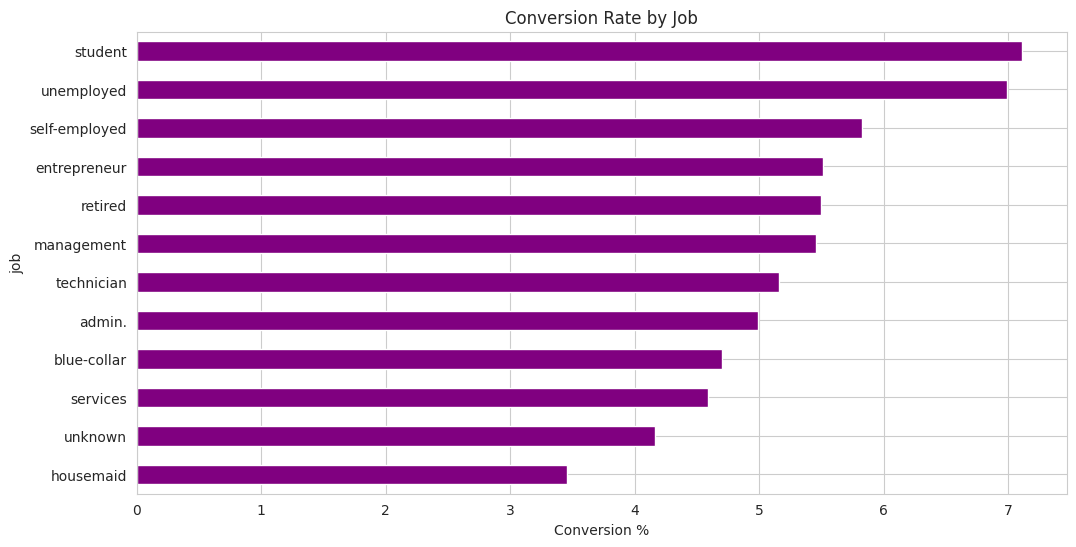

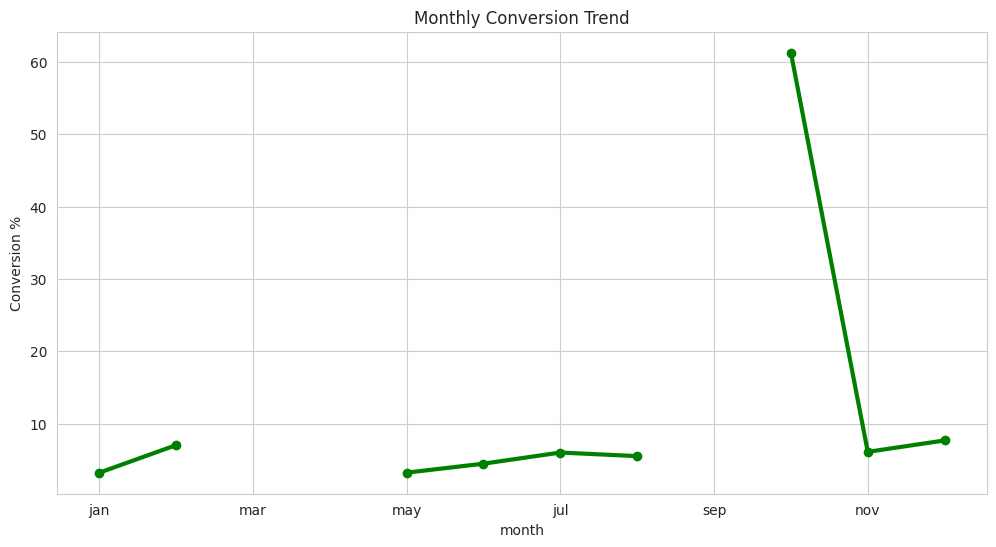

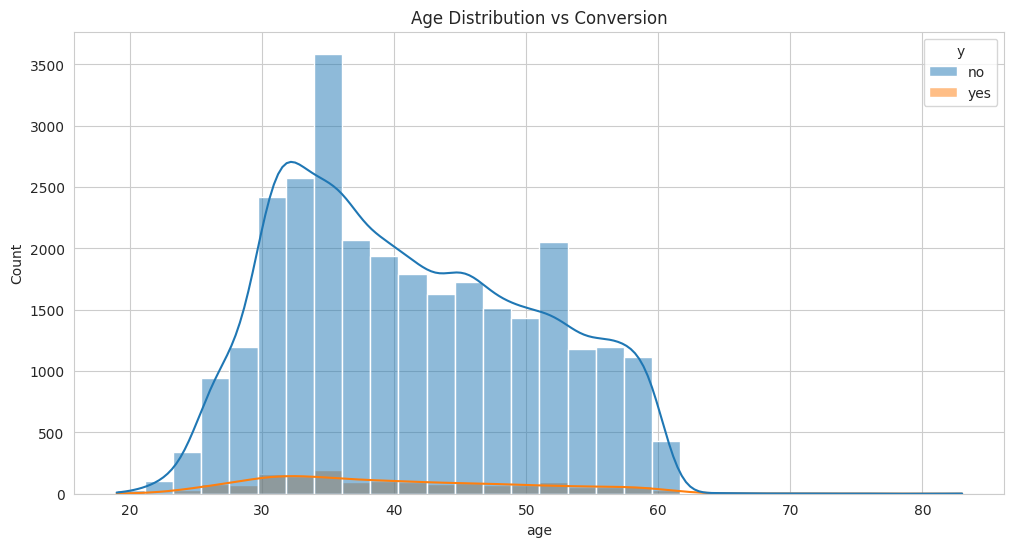

/tmp/ipykernel_10270/3669478684.py:86: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




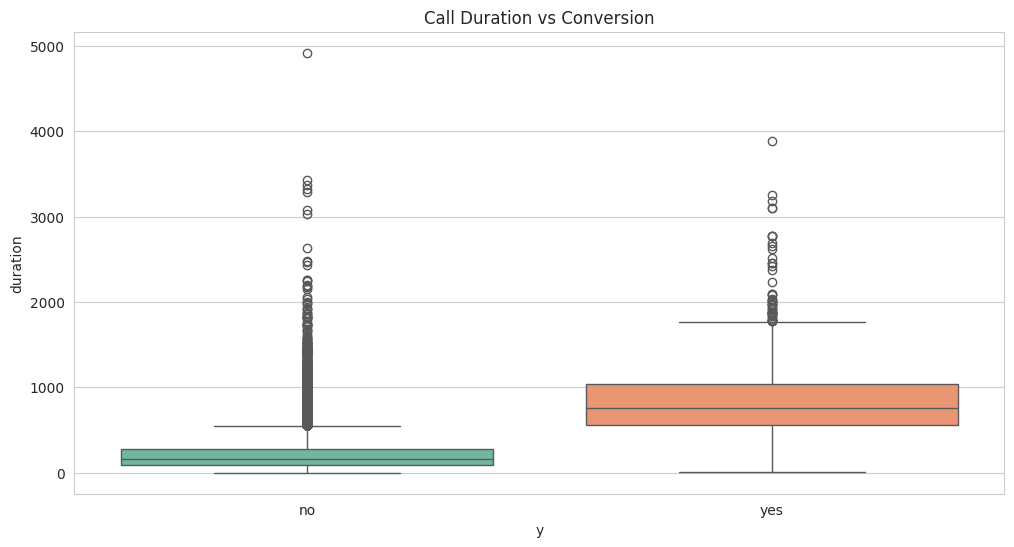

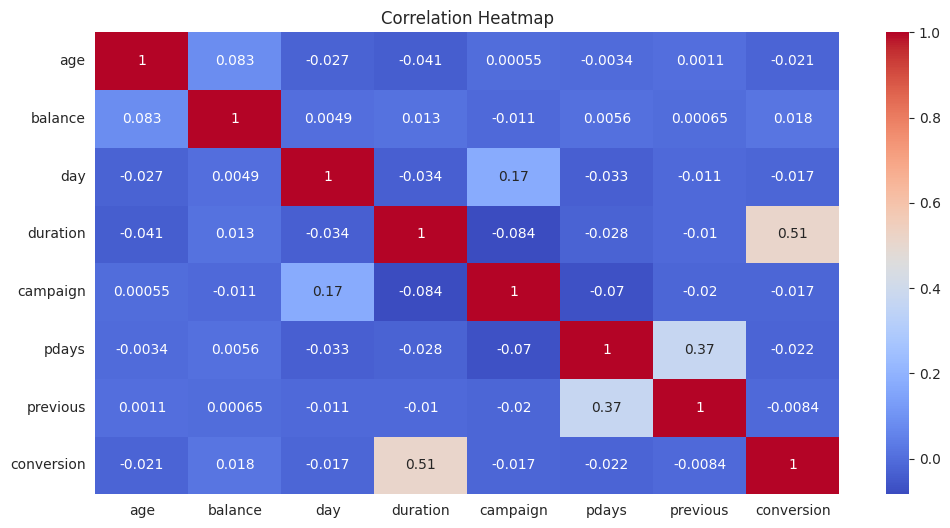

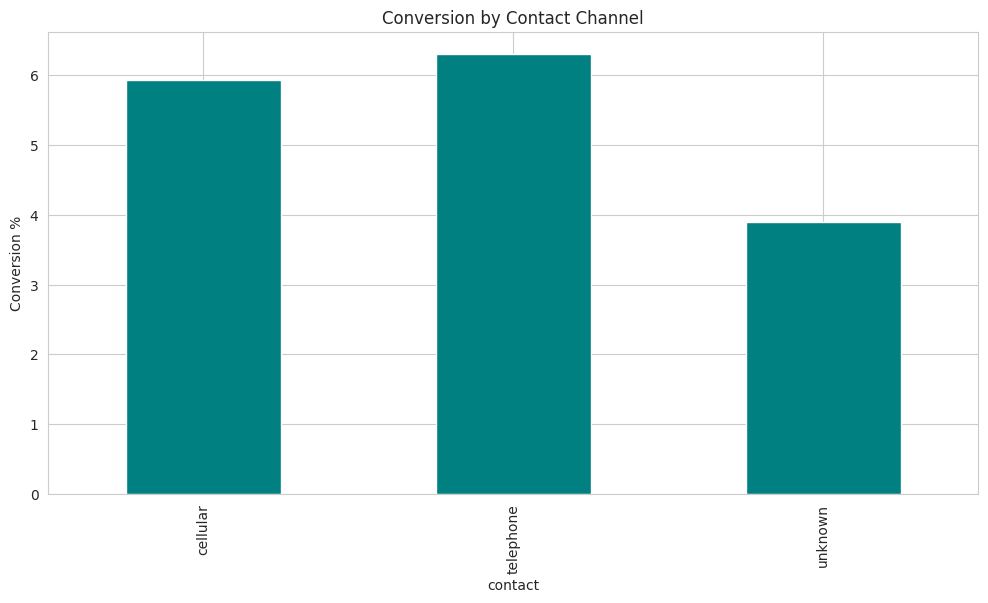


===== KPI SUMMARY =====
Total Leads: 30880
Contacted: 18115
Engaged: 14656
Converted: 1578
Conversion Rate: 5.11 %


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio

# =========================
# SETUP
# =========================
pio.renderers.default = "colab"
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

# =========================
# LOAD DATA (SAFE)
# =========================
df = pd.read_csv(
    '/content/bank-full.csv',
    sep=';',
    engine='python',
    on_bad_lines='skip'
)

# =========================
# FEATURE ENGINEERING
# =========================
df['conversion'] = df['y'].map({'yes':1, 'no':0})

# =========================
# FUNNEL DATA
# =========================
total = len(df)
contacted = df[df['contact'] != 'unknown'].shape[0]
engaged = df[df['duration'] > 180].shape[0]
converted = df[df['conversion'] == 1].shape[0]

# =========================
# 1. FUNNEL CHART
# =========================
fig1 = go.Figure(go.Funnel(
    y=["Leads", "Contacted", "Engaged", "Converted"],
    x=[total, contacted, engaged, converted],
    textinfo="value+percent initial"
))
fig1.update_layout(title="Marketing Funnel")
fig1.show()

# =========================
# 2. BAR CHART - Conversion by Job
# =========================
job_conv = df.groupby('job')['conversion'].mean()*100

job_conv.sort_values().plot(kind='barh', color='purple')
plt.title("Conversion Rate by Job")
plt.xlabel("Conversion %")
plt.show()

# =========================
# 3. LINE CHART - Monthly Trend
# =========================
month_order = [
    'jan','feb','mar','apr','may','jun',
    'jul','aug','sep','oct','nov','dec'
]

month_conv = df.groupby('month')['conversion'].mean()*100
month_conv = month_conv.reindex(month_order)

month_conv.plot(marker='o', color='green', linewidth=3)
plt.title("Monthly Conversion Trend")
plt.ylabel("Conversion %")
plt.show()

# =========================
# 4. DISTRIBUTION - Age vs Conversion
# =========================
sns.histplot(data=df, x='age', hue='y', bins=30, kde=True)
plt.title("Age Distribution vs Conversion")
plt.show()

# =========================
# 5. BOX PLOT - Duration Impact
# =========================
sns.boxplot(data=df, x='y', y='duration', palette='Set2')
plt.title("Call Duration vs Conversion")
plt.show()

# =========================
# 6. HEATMAP - Correlation
# =========================
numeric = df.select_dtypes(include=np.number)
sns.heatmap(numeric.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# =========================
# 7. CHANNEL PERFORMANCE
# =========================
channel = df.groupby('contact')['conversion'].mean()*100
channel.plot(kind='bar', color='teal')
plt.title("Conversion by Contact Channel")
plt.ylabel("Conversion %")
plt.show()

# =========================
# 8. SCATTER PLOT - Balance vs Duration
# =========================
sample = df.sample(3000)

fig2 = px.scatter(
    sample,
    x='balance',
    y='duration',
    color='y',
    size='age',
    title="Balance vs Duration (Conversion View)"
)

fig2.show()

# =========================
# 9. KPI SUMMARY
# =========================
print("\n===== KPI SUMMARY =====")
print("Total Leads:", total)
print("Contacted:", contacted)
print("Engaged:", engaged)
print("Converted:", converted)
print("Conversion Rate:", round(converted/total*100,2), "%")